In [1]:
!pip install nltk spacy scikit-learn pandas numpy seaborn matplotlib gensim
!python -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     --------------------------------------- 0.0/12.8 MB 165.2 kB/s eta 0:01:18
     --------------------------------------- 0.0/12.8 MB 187.9 kB/s eta 0:01:08
     --------------------------------------- 0.1/12.8 MB 297.7 kB/s eta 0:00:43
     --------------------------------------- 0.1/12.8 MB 514.3 kB/s eta 0:00:25
      -------------------------------------- 0.3/12.8 MB 923.9 kB/s eta 0:00:14
     - -------------------------------------- 0.5/12.8 MB 1.6 MB/s eta 0:00:08
     -- ------------------------------------- 0.9/12.8 MB 2.6 MB/s eta 0:00:05
     ---- ----------------------------------- 1.5/12.8 MB 3.6 MB/s eta 0:00:04
     ------- -------------------------------- 2.5/12.8 MB 5.5 MB/s eta 0:00:02
     ------------- -------------------------- 4.2/12.8 MB 8.3 MB/s eta 0:00:02
     ------------------ --------------------- 5.9/12.8 MB 10.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
import string

# NLTK modules
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Sklearn modules
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [3]:
# Step 2 — Load the Dataset

# Load CSV files
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

print("Fake shape:", fake.shape)
print("True shape:", true.shape)

# Add labels according to checklist
fake['label'] = 0   # Fake news
true['label'] = 1   # Real news

# Keep only text + label columns
fake = fake[['text', 'label']]
true = true[['text', 'label']]

# Combine datasets
df = pd.concat([fake, true], axis=0)

# Shuffle dataset
df = df.sample(frac=1).reset_index(drop=True)

# -----------------------------
# Basic Inspection (Checklist)
# -----------------------------

print("\nDataset Shape:", df.shape)
print("\nNull Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

df.head()


Fake shape: (23481, 4)
True shape: (21417, 4)

Dataset Shape: (44898, 2)

Null Values:
 text     0
label    0
dtype: int64

Duplicate Rows: 6251


,text,label
0,"After watching this video, one thing is abunda...",0
1,There is nothing about Obama s executive order...,0
2,Donald Trump s former campaign manager Paul Ma...,0
3,21st Century Wire says A greater percentage of...,0
4,BERLIN (Reuters) - It is up to Britain to move...,1


In [4]:
# Drop duplicate rows based on 'text' column
df = df.drop_duplicates(subset='text', keep='first').reset_index(drop=True)

# Check again
print("Shape after removing duplicates:", df.shape)
print("Duplicate Rows now:", df.duplicated().sum())
df.head()


Shape after removing duplicates: (38646, 2)
Duplicate Rows now: 0


,text,label
0,"After watching this video, one thing is abunda...",0
1,There is nothing about Obama s executive order...,0
2,Donald Trump s former campaign manager Paul Ma...,0
3,21st Century Wire says A greater percentage of...,0
4,BERLIN (Reuters) - It is up to Britain to move...,1


In [5]:
# Step 3 — Text Cleaning

import re
import string

def clean_text(text):
    text = text.lower()  # lowercase
    text = re.sub(r'http\S+|www\S+', '', text)  # remove URLs
    text = re.sub(r'<.*?>', '', text)           # remove HTML tags
    text = re.sub(r'\d+', '', text)             # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    text = text.strip()  # remove leading/trailing whitespace
    return text

# Apply cleaning
df['clean_text'] = df['text'].apply(clean_text)

# Check first few rows
df[['text','clean_text','label']].head()


,text,clean_text,label
0,"After watching this video, one thing is abunda...",after watching this video one thing is abundan...,0
1,There is nothing about Obama s executive order...,there is nothing about obama s executive order...,0
2,Donald Trump s former campaign manager Paul Ma...,donald trump s former campaign manager paul ma...,0
3,21st Century Wire says A greater percentage of...,st century wire says a greater percentage of p...,0
4,BERLIN (Reuters) - It is up to Britain to move...,berlin reuters it is up to britain to move br...,1


In [6]:
import nltk

nltk.download('punkt')      # Tokenizer
nltk.download('stopwords')  # Common stopwords
nltk.download('wordnet')    # Lemmatizer


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [7]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Stopwords and Lemmatizer
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    # 1. Tokenize
    tokens = word_tokenize(text)
    
    # 2. Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]
    
    # 3. Lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    # Join tokens back to string
    return " ".join(tokens)

# Apply preprocessing
df['processed_text'] = df['clean_text'].apply(preprocess)

# Check first few rows
df[['clean_text','processed_text','label']].head()


,clean_text,processed_text,label
0,after watching this video one thing is abundan...,watching video one thing abundantly clear come...,0
1,there is nothing about obama s executive order...,nothing obama executive order gun grab barack ...,0
2,donald trump s former campaign manager paul ma...,donald trump former campaign manager paul mana...,0
3,st century wire says a greater percentage of p...,st century wire say greater percentage people ...,0
4,berlin reuters it is up to britain to move br...,berlin reuters britain move brexit talk forwar...,1


In [9]:
# Features and labels
X = df['processed_text']
y = df['label']

# Split 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 30916
Testing samples: 7730


In [10]:
# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=5000)  # Top 5000 words

# Fit on training data & transform
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Shape of X_train TF-IDF:", X_train_tfidf.shape)
print("Shape of X_test TF-IDF:", X_test_tfidf.shape)


Shape of X_train TF-IDF: (30916, 5000)
Shape of X_test TF-IDF: (7730, 5000)



--- Logistic Regression ---
Accuracy: 0.9836

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      3491
           1       0.98      0.99      0.99      4239

    accuracy                           0.98      7730
   macro avg       0.98      0.98      0.98      7730
weighted avg       0.98      0.98      0.98      7730



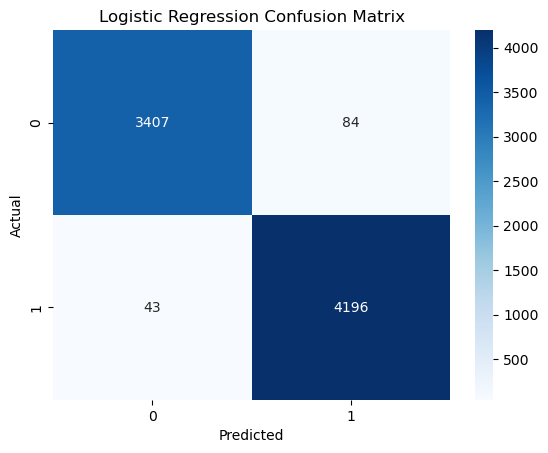


--- Support Vector Machine ---
Accuracy: 0.9894

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      3491
           1       0.99      0.99      0.99      4239

    accuracy                           0.99      7730
   macro avg       0.99      0.99      0.99      7730
weighted avg       0.99      0.99      0.99      7730



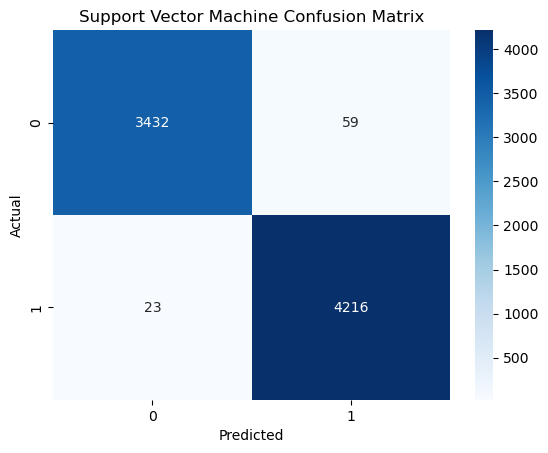


--- Random Forest ---
Accuracy: 0.9935

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3491
           1       0.99      1.00      0.99      4239

    accuracy                           0.99      7730
   macro avg       0.99      0.99      0.99      7730
weighted avg       0.99      0.99      0.99      7730



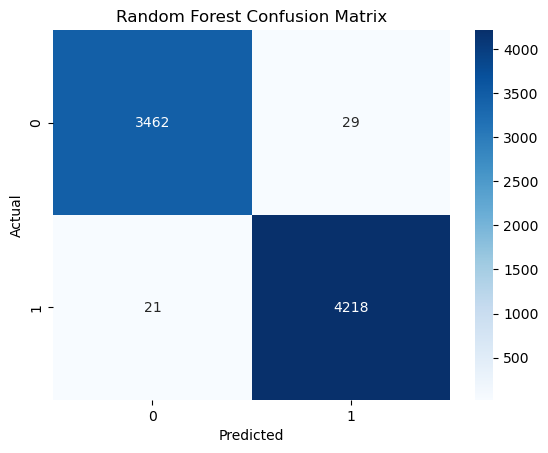

In [11]:

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier


# 1️⃣ Initialize Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Support Vector Machine": SVC(kernel='linear', probability=False),  # Faster
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}


# 2️⃣ Train, Predict & Evaluate
for name, model in models.items():
    print(f"\n--- {name} ---")
    
    # Train
    model.fit(X_train_tfidf, y_train)
    
    # Predict
    y_pred = model.predict(X_test_tfidf)
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")
    
    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


In [14]:
# Choose a model for error analysis
model = models["Support Vector Machine"]

# Predict
y_pred = model.predict(X_test_tfidf)

## Recreate test dataframe properly
test_index = X_test.index   # original text index

error_df = pd.DataFrame({
    "text": df.loc[test_index, "text"].values,
    "actual": y_test.values,
    "predicted": y_pred
})

# Find misclassified rows
misclassified = error_df[error_df["actual"] != error_df["predicted"]]
misclassified.head(10)


,text,actual,predicted
228,21st Century Wire says There have been a strin...,0,1
254,(Reuters) - Melania Trump rose to her husband’...,1,0
275,How about America calls him out for arming ISI...,0,1
461,North Korea said on Monday it had successfully...,0,1
600,Reuters is reporting: U.S. President Donald T...,0,1
721,Pregnant women throughout the America s are th...,0,1
762,If the Obama regime is allowed to wrest contro...,0,1
804,Obama s war on America just got real These act...,0,1
853,O Connor found that the plaintiffs had standin...,0,1
871,"To hear Donald Trump tell it, he s the best, h...",0,1


In [15]:
misclassified[['text', 'actual', 'predicted']].head(10)


,text,actual,predicted
228,21st Century Wire says There have been a strin...,0,1
254,(Reuters) - Melania Trump rose to her husband’...,1,0
275,How about America calls him out for arming ISI...,0,1
461,North Korea said on Monday it had successfully...,0,1
600,Reuters is reporting: U.S. President Donald T...,0,1
721,Pregnant women throughout the America s are th...,0,1
762,If the Obama regime is allowed to wrest contro...,0,1
804,Obama s war on America just got real These act...,0,1
853,O Connor found that the plaintiffs had standin...,0,1
871,"To hear Donald Trump tell it, he s the best, h...",0,1


In [16]:
fake_to_real = ((misclassified['actual'] == 0) & (misclassified['predicted'] == 1)).sum()
real_to_fake = ((misclassified['actual'] == 1) & (misclassified['predicted'] == 0)).sum()

print("Fake → Real:", fake_to_real)
print("Real → Fake:", real_to_fake)


Fake → Real: 59
Real → Fake: 23


In [17]:
misclassified["length"] = misclassified["text"].apply(len)
misclassified.sort_values("length", ascending=False).head(5)[["text", "actual", "predicted", "length"]]


C:\Users\User\AppData\Local\Temp\ipykernel_20324\568896212.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  misclassified["length"] = misclassified["text"].apply(len)


,text,actual,predicted,length
3742,"MIDDLETOWN, CONN. - Two years ago, Judy Konopk...",1,0,18633
5802,(Reuters) - The following is the full text of ...,1,0,12504
1819,Duterte takes clear lead in Philippine electi...,0,1,10571
5488,The Obama administration plans to announce on ...,0,1,9831
2997,Follow the money on this one Mexico is spendin...,0,1,8272


In [19]:
!pip install wordcloud


   ---------------------------------------- 0.0/301.2 kB ? eta -:--:--
   - -------------------------------------- 10.2/301.2 kB ? eta -:--:--
   - -------------------------------------- 10.2/301.2 kB ? eta -:--:--
   --- ----------------------------------- 30.7/301.2 kB 217.9 kB/s eta 0:00:02
   ----- --------------------------------- 41.0/301.2 kB 217.9 kB/s eta 0:00:02
   ------- ------------------------------- 61.4/301.2 kB 251.0 kB/s eta 0:00:01
   --------- ----------------------------- 71.7/301.2 kB 261.4 kB/s eta 0:00:01
   --------------- ---------------------- 122.9/301.2 kB 379.3 kB/s eta 0:00:01
   ------------------- ------------------ 153.6/301.2 kB 435.7 kB/s eta 0:00:01
   ---------------------------- --------- 225.3/301.2 kB 573.4 kB/s eta 0:00:01
   -------------------------------------  297.0/301.2 kB 679.4 kB/s eta 0:00:01
   -------------------------------------- 301.2/301.2 kB 689.4 kB/s eta 0:00:00


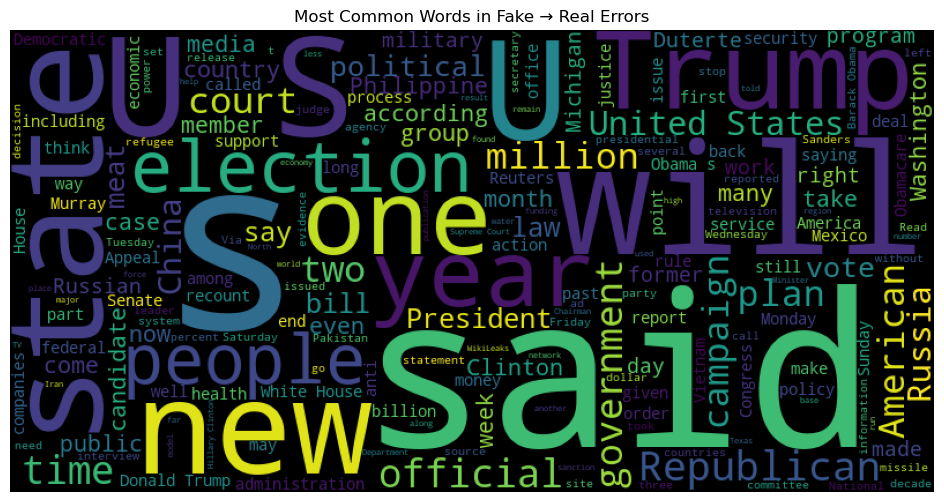

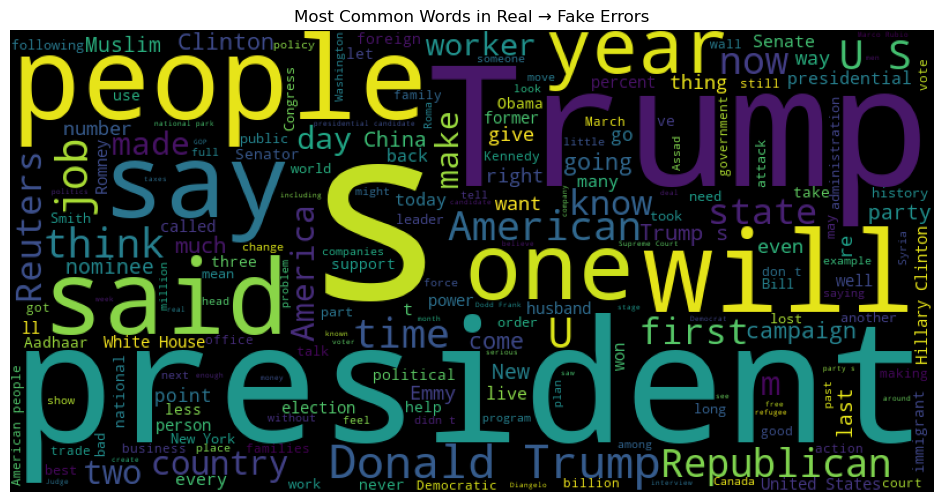

In [20]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

fake_errors = misclassified[misclassified["actual"] == 0]["text"].str.cat(sep=" ")
real_errors = misclassified[misclassified["actual"] == 1]["text"].str.cat(sep=" ")

plt.figure(figsize=(12,6))
plt.imshow(WordCloud(width=800, height=400).generate(fake_errors))
plt.title("Most Common Words in Fake → Real Errors")
plt.axis("off")
plt.show()

plt.figure(figsize=(12,6))
plt.imshow(WordCloud(width=800, height=400).generate(real_errors))
plt.title("Most Common Words in Real → Fake Errors")
plt.axis("off")
plt.show()


In [23]:
import joblib

# Save the trained model (example: Logistic Regression)
joblib.dump(model, "fake_news_model.pkl")

# Save TF-IDF vectorizer
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model and TF-IDF vectorizer saved successfully!")


Model and TF-IDF vectorizer saved successfully!


In [24]:
# Load model
loaded_model = joblib.load("fake_news_model.pkl")

# Load TF-IDF
loaded_tfidf = joblib.load("tfidf_vectorizer.pkl")


In [25]:
def predict_news(text):
    # Clean text
    cleaned = clean_text(text)
    
    # Preprocess
    processed = preprocess(cleaned)
    
    # Vectorize
    vector = loaded_tfidf.transform([processed])
    
    # Predict
    pred = loaded_model.predict(vector)[0]
    
    # Return label
    return "REAL NEWS 🟢" if pred == 1 else "FAKE NEWS 🔴"


In [26]:
print(predict_news("Government approves new bill for education reforms."))
print(predict_news("Aliens have landed in New York City and taken over the government."))


FAKE NEWS 🔴
FAKE NEWS 🔴
